# Mall Customer Segmentation with K-Means Clustering

**Goal:** Group mall customers into distinct segments based on annual
income and spending score, so a business could target each group with a
different marketing strategy.

**Skills demonstrated:** EDA with Pandas/Matplotlib, feature scaling,
unsupervised learning (K-Means), choosing K with the elbow method,
cluster visualization and interpretation.

**Dataset:** Mall Customer Segmentation dataset (200 customers: age,
annual income, spending score).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RANDOM_STATE = 42

## 1. Load data

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.columns = ["CustomerID", "Genre", "Age", "AnnualIncome", "SpendingScore"]
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Genre,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Feature selection & scaling

Cluster on `AnnualIncome` and `SpendingScore` — the two features that
most directly describe customer purchasing behavior. K-Means uses
Euclidean distance, so scale both features first.

In [3]:
X = df[["AnnualIncome", "SpendingScore"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Choose K with the elbow method

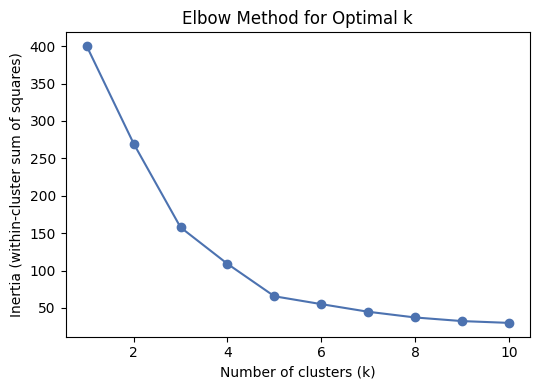

In [4]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(5.5, 4))
plt.plot(list(k_range), inertias, marker="o", color="#4C72B0")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=150)
plt.show()

The "elbow" — where adding another cluster stops meaningfully reducing
inertia — is clearly at **k = 5** for this dataset.

In [5]:
K_FINAL = 5
kmeans = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE)
df["Cluster"] = kmeans.fit_predict(X_scaled)

## 4. Visualize clusters

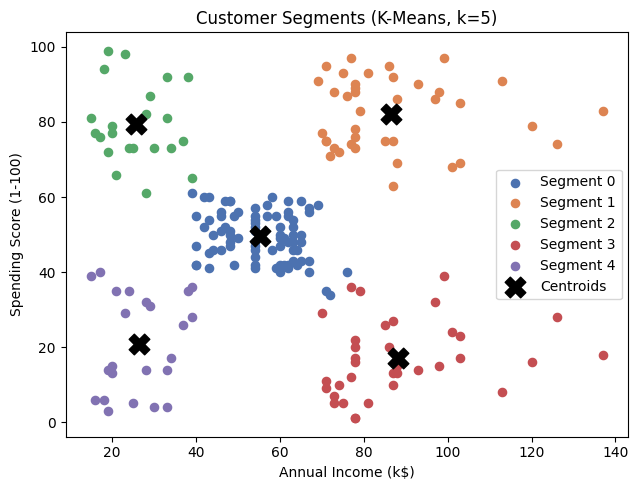

In [6]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(6.5, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
for cluster_id in range(K_FINAL):
    cluster_points = df[df["Cluster"] == cluster_id]
    plt.scatter(cluster_points["AnnualIncome"], cluster_points["SpendingScore"],
                s=35, color=colors[cluster_id], label=f"Segment {cluster_id}")
plt.scatter(centers[:, 0], centers[:, 1], s=220, c="black", marker="X", label="Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"Customer Segments (K-Means, k={K_FINAL})")
plt.legend()
plt.tight_layout()
plt.savefig("customer_segments.png", dpi=150)
plt.show()

## 5. Interpret segments

In [7]:
summary = df.groupby("Cluster")[["Age", "AnnualIncome", "SpendingScore"]].mean().round(1)
summary["Count"] = df.groupby("Cluster").size()
summary

,Age,AnnualIncome,SpendingScore,Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


## Results summary

Five clear customer segments emerged:

| Segment | Profile |
|---|---|
| 0 | Mid-age, mid-income, mid-spending — the "average" customer (81 people) |
| 1 | Younger, high-income, **high spending** — prime target for premium offers (39 people) |
| 2 | Young, low-income, but **high spending** — price-sensitive but engaged shoppers (22 people) |
| 3 | Mid-age, high-income, **low spending** — high potential, needs re-engagement (35 people) |
| 4 | Older, low-income, low spending — minimal marketing priority (23 people) |

A business could use this to focus retention campaigns on Segment 3
(high income, low spending — there's untapped potential) and loyalty
perks on Segment 1 (already the most valuable group).